In [1]:
import os

In [2]:
from dotenv import load_dotenv

In [3]:
load_dotenv()

True

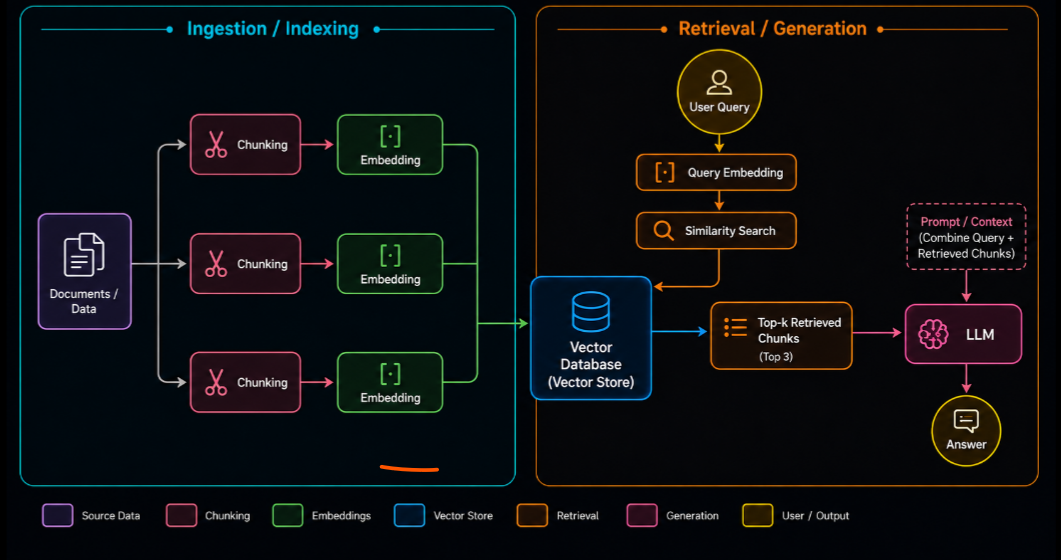

In [4]:
GOOGLE_API_KEY = os.getenv("GOOGLE_API_KEY")

In [5]:
GROQ_API_KEY=os.getenv("GROQ_API_KEY")

In [6]:
os.environ["GOOGLE_API_KEY"] = GOOGLE_API_KEY

In [7]:
os.environ["GROQ_API_KEY"] = GROQ_API_KEY

In [8]:
from langchain_google_genai import GoogleGenerativeAIEmbeddings
embeddings = GoogleGenerativeAIEmbeddings(model="gemini-embedding-001")

In [9]:
os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")

In [11]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer(
    "BAAI/bge-small-en-v1.5"
)

texts = [
    "Venkatesh is an AI Engineer.",
    "Pattern Recognition grade: 2.3, ECTS: 5",
    "M.Sc. Data Science at FAU Erlangen-Nürnberg."
]

embeddings = model.encode(
    texts,
    normalize_embeddings=True
)

print(embeddings.shape)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

c:\Users\ASUS\Desktop\Gen AI Full stak\env\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\ASUS\.cache\huggingface\hub\models--BAAI--bge-small-en-v1.5. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

(3, 384)


In [15]:
from langchain_huggingface import HuggingFaceEmbeddings


embeddings = HuggingFaceEmbeddings(
    model_name="BAAI/bge-small-en-v1.5",
    model_kwargs={
        "device": "cpu"
    },
    encode_kwargs={
        "normalize_embeddings": True
    }
)


# Single query
query_vector = embeddings.embed_query(
    "Hello world"
)

print(type(query_vector))
print(len(query_vector))


<class 'list'>
384


In [16]:
documents = [
    "Venkatesh is an AI Engineer.",
    "Venkatesh studies Data Science at FAU.",
    "Pattern Recognition grade is 2.3."
]

document_vectors = embeddings.embed_documents(
    documents
)

print(len(document_vectors))
print(len(document_vectors[0]))

3
384


In [14]:
embeddings.embed_query("Hello world")

AttributeError: 'numpy.ndarray' object has no attribute 'embed_query'

In [11]:
from langchain_openai import OpenAIEmbeddings

In [72]:
embeddings=OpenAIEmbeddings(model="text-embedding-3-large")

In [12]:
embeddings=OpenAIEmbeddings(model="text-embedding-3-small")

In [13]:
embeddings.embed_query("Hello world")

[-0.0021610260009765625,
 -0.049072265625,
 0.0209808349609375,
 0.0313720703125,
 -0.045318603515625,
 -0.0264129638671875,
 -0.028961181640625,
 0.060302734375,
 -0.0257110595703125,
 -0.0148162841796875,
 0.015472412109375,
 -0.0300445556640625,
 -0.0203704833984375,
 -0.033416748046875,
 0.0258331298828125,
 0.01422119140625,
 -0.070068359375,
 0.0123748779296875,
 0.01483917236328125,
 0.048919677734375,
 0.020782470703125,
 -0.00887298583984375,
 -0.0151214599609375,
 -0.016632080078125,
 0.0259552001953125,
 -0.002857208251953125,
 -0.024383544921875,
 0.0242919921875,
 0.0018329620361328125,
 -0.05572509765625,
 0.023101806640625,
 -0.04547119140625,
 -0.00870513916015625,
 0.0030956268310546875,
 0.004558563232421875,
 0.0018224716186523438,
 0.0266876220703125,
 0.01013946533203125,
 -0.01201629638671875,
 -0.0115203857421875,
 -0.01491546630859375,
 -0.0231475830078125,
 0.025390625,
 0.03680419921875,
 -0.035491943359375,
 0.02130126953125,
 -0.0631103515625,
 0.04037475585

In [17]:
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS


# ============================================================
# 1. PDF PATH
# ============================================================

pdf_path = r"C:\Users\ASUS\Desktop\Gen AI Full stak\class_19_end_to_end_RAG\Venkatesh_Vemala_Personal_RAG_Knowledge_Base.pdf"


# ============================================================
# 2. LOAD PDF
# ============================================================

loader = PyPDFLoader(pdf_path)

documents = loader.load()

print("Pages loaded:", len(documents))


# ============================================================
# 3. SPLIT INTO CHUNKS
# ============================================================

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=800,
    chunk_overlap=150,
)

chunks = text_splitter.split_documents(
    documents
)

print("Chunks created:", len(chunks))


# ============================================================
# 4. EMBEDDING MODEL
# ============================================================

embeddings = HuggingFaceEmbeddings(
    model_name="BAAI/bge-small-en-v1.5",
    model_kwargs={
        "device": "cpu"
    },
    encode_kwargs={
        "normalize_embeddings": True
    },
)


# ============================================================
# 5. TEST SINGLE QUERY EMBEDDING
# ============================================================

query_vector = embeddings.embed_query(
    "What is Venkatesh's education?"
)

print("Embedding length:", len(query_vector))


# ============================================================
# 6. CREATE VECTOR DATABASE
# ============================================================

vectorstore = FAISS.from_documents(
    chunks,
    embeddings,
)

print("FAISS vector database created.")


# ============================================================
# 7. TEST RETRIEVAL
# ============================================================

results = vectorstore.similarity_search(
    "What subjects has Venkatesh studied?",
    k=3,
)


for i, doc in enumerate(results, start=1):

    print("\n" + "=" * 60)
    print(f"RESULT {i}")
    print("=" * 60)

    print(doc.page_content)

    print("\nMetadata:")
    print(doc.metadata)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_37436\3240507123.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader


Pages loaded: 8
Chunks created: 24
Embedding length: 384
FAISS vector database created.

RESULT 1
automatic behavior accuracy; DPO scored 81.3%.
 Venkatesh is Google Cloud Certified as an Associate Cloud Engineer.
 Language proficiency listed in the CV: English C1 and German A1.
16. Suggested Questions This RAG Document Should Answer
1. Who is Venkatesh Vemala?
2. What is Venkatesh currently studying?
3. Which university does Venkatesh attend?
4. What subjects has Venkatesh passed in the Data Science master's program?
5. What is Venkatesh's current ECTS total and average grade?
6. What machine learning and AI courses has Venkatesh completed?
7. What professional experience does Venkatesh have?
8. What did Venkatesh do at Siemens Healthineers?
9. What did Venkatesh do at Accenture?
10. Which cloud technologies does Venkatesh know?
11. What projects has Venkatesh completed?

Metadata:
{'producer': 'LibreOffice 25.2.3.2 (X86_64) / LibreOffice Community', 'creator': 'Writer', 'creationda

In [18]:
embeddings.embed_query(
    "Hello world"
)

[0.01519606914371252,
 -0.022570684552192688,
 0.008547081612050533,
 -0.0741705670952797,
 0.0038364084903150797,
 0.002713541965931654,
 -0.031267937272787094,
 0.044634025543928146,
 0.04405519738793373,
 -0.007871163077652454,
 -0.025200804695487022,
 -0.03336656838655472,
 0.014427870512008667,
 0.04653821140527725,
 0.008555072359740734,
 -0.01614576391875744,
 0.007405796553939581,
 -0.019012443721294403,
 -0.1147262379527092,
 -0.018157614395022392,
 0.12635937333106995,
 0.029702896252274513,
 0.025281021371483803,
 -0.03421788290143013,
 -0.040999636054039,
 0.006617328152060509,
 0.010270613245666027,
 0.02236226387321949,
 0.004436326213181019,
 -0.1273096203804016,
 -0.01614924520254135,
 -0.02038019336760044,
 0.04721207544207573,
 0.011579924263060093,
 0.0681871697306633,
 0.00729863066226244,
 -0.017852986231446266,
 0.040782153606414795,
 -0.01026942115277052,
 0.023757077753543854,
 0.010602925904095173,
 -0.028584426268935204,
 0.008159685879945755,
 -0.015180529095

In [53]:
from langchain_google_genai import ChatGoogleGenerativeAI
llm = ChatGoogleGenerativeAI(model="gemini-3.1-flash-lite")

In [15]:
llm.invoke("hi how are you?").content[0]["text"]

"I'm doing great, thank you for asking! How are you doing today? Is there anything I can help you with?"

#### It is simple AI Assistant without RAG Pipelie

In [108]:
while True:
    user_input = input("You: ")
    if user_input.lower() in ["exit", "quit"]:
        print("Exiting the chat. Goodbye!")
        break
    response = llm.invoke(user_input).content[0]["text"]
    print(f"AI: {response}")

AI: As of right now, **there is no such model as "DeepSeek-V4-Pro."**

It is likely you are conflating several different naming conventions. Here is the current status of the DeepSeek model lineup:

1.  **DeepSeek-V3:** This is the latest flagship model released by DeepSeek. It is a Mixture-of-Experts (MoE) model with **671 billion parameters** in total, of which approximately 37 billion are active per token.
2.  **DeepSeek-R1:** This is the latest reasoning-focused model. It is based on the DeepSeek-V3 architecture and shares the same scale (671 billion parameters total).
3.  **Future Versions:** DeepSeek has not announced a "V4" or any "Pro" version of their models.

If you are seeing references to a "DeepSeek-V4-Pro" online, it is almost certainly a hallucination, a misunderstanding of the current version numbers, or misinformation. 

**Summary of the current flagship (DeepSeek-V3/R1):**
*   **Total Parameters:** 671 Billion
*   **Active Parameters:** ~37 Billion
*   **Architecture:

In [20]:
from langchain_community.document_loaders import TextLoader, DirectoryLoader

In [21]:
from langchain_community.document_loaders import WebBaseLoader

USER_AGENT environment variable not set, consider setting it to identify your requests.


In [22]:
from langchain_community.document_loaders import PyPDFLoader

In [23]:
file_path = r"C:\Users\ASUS\Desktop\Gen AI Full stak\class_19_end_to_end_RAG\Venkatesh_Vemala_Personal_RAG_Knowledge_Base.pdf"

In [24]:
pages = PyPDFLoader(file_path).load()

In [25]:
len(pages)

8

In [80]:
pages

[Document(metadata={'producer': 'pikepdf 8.15.1', 'creator': 'arXiv GenPDF (tex2pdf:a6404ea)', 'creationdate': '', 'author': 'DeepSeek-AI; Anyi Xu; Bangcai Lin; Bing Xue; Bingxuan Wang; Bingzheng Xu; Bochao Wu; Bowei Zhang; Chaofan Lin; Chen Dong; Chenchen Ling; Chengda Lu; Chenggang Zhao; Chengqi Deng; Chengyu Hou; Chenhao Xu; Chenze Shao; Chong Ruan; Conner Sun; Damai Dai; Daya Guo; Dejian Yang; Deli Chen; Donghao Li; Dongjie Ji; Erhang Li; Fang Wei; Fangyun Lin; Fangzhou Yuan; Feiyu Xia; Fucong Dai; Guangbo Hao; Guanting Chen; Guoai Cao; Guolai Meng; Guowei Li; Han Yu; Han Zhang; Hanwei Xu; Hao Li; Haofen Liang; Haoling Zhang; Haoming Luo; Haoran Wei; Haotian Yuan; Haowei Zhang; Haowen Luo; Haoyu Chen; Haozhe Ji; Hengqing Zhang; Honghui Ding; Hongxuan Tang; Huanqi Cao; Huazuo Gao; Hui Qu; Hui Zeng; J Yang; JQ Zhu; Jia Luo; Jia Song; Jia Yu; Jialiang Huang; Jialu Cai; Jian Liang; Jiangting Zhou; Jiasheng Ye; Jiashi Li; Jiaxin Xu; Jiewen Hu; Jieyu Yang; Jin Chen; Jin Yan; Jingchang Ch

In [26]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

In [27]:
#parameter values will discuss in the upcoming session
chunker =RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=400)

In [28]:
chunked_data = chunker.split_documents(pages)

In [29]:
len(chunked_data)

24

In [30]:
chunked_data

[Document(metadata={'producer': 'LibreOffice 25.2.3.2 (X86_64) / LibreOffice Community', 'creator': 'Writer', 'creationdate': '2026-09-17T19:45:42+00:00', 'author': 'python-docx', 'source': 'C:\\Users\\ASUS\\Desktop\\Gen AI Full stak\\class_19_end_to_end_RAG\\Venkatesh_Vemala_Personal_RAG_Knowledge_Base.pdf', 'total_pages': 8, 'page': 0, 'page_label': '1'}, page_content='Venkatesh Vemala - Personal RAG Knowledge Base | Page 1\nVenkatesh Vemala - Personal RAG \nKnowledge Base\nStructured profile, professional experience, education, academic record, skills, projects and research \ncontext\nPrepared from the supplied CV, FAU examination record, and project details provided in this conversation.\nPRIVATE RAG DATASET: This document intentionally contains personal contact details and academic \nidentifiers from the supplied documents. Do not publish or share it publicly without redaction.\n1. Identity and Contact Information\nFull name: Venkatesh Vemala\nProfessional title: AI Engineer\nEmai

In [31]:
chunked_data[0]

Document(metadata={'producer': 'LibreOffice 25.2.3.2 (X86_64) / LibreOffice Community', 'creator': 'Writer', 'creationdate': '2026-09-17T19:45:42+00:00', 'author': 'python-docx', 'source': 'C:\\Users\\ASUS\\Desktop\\Gen AI Full stak\\class_19_end_to_end_RAG\\Venkatesh_Vemala_Personal_RAG_Knowledge_Base.pdf', 'total_pages': 8, 'page': 0, 'page_label': '1'}, page_content='Venkatesh Vemala - Personal RAG Knowledge Base | Page 1\nVenkatesh Vemala - Personal RAG \nKnowledge Base\nStructured profile, professional experience, education, academic record, skills, projects and research \ncontext\nPrepared from the supplied CV, FAU examination record, and project details provided in this conversation.\nPRIVATE RAG DATASET: This document intentionally contains personal contact details and academic \nidentifiers from the supplied documents. Do not publish or share it publicly without redaction.\n1. Identity and Contact Information\nFull name: Venkatesh Vemala\nProfessional title: AI Engineer\nEmail

In [32]:
chunked_data[0].metadata

{'producer': 'LibreOffice 25.2.3.2 (X86_64) / LibreOffice Community',
 'creator': 'Writer',
 'creationdate': '2026-09-17T19:45:42+00:00',
 'author': 'python-docx',
 'source': 'C:\\Users\\ASUS\\Desktop\\Gen AI Full stak\\class_19_end_to_end_RAG\\Venkatesh_Vemala_Personal_RAG_Knowledge_Base.pdf',
 'total_pages': 8,
 'page': 0,
 'page_label': '1'}

In [33]:
chunked_data[0].page_content

'Venkatesh Vemala - Personal RAG Knowledge Base | Page 1\nVenkatesh Vemala - Personal RAG \nKnowledge Base\nStructured profile, professional experience, education, academic record, skills, projects and research \ncontext\nPrepared from the supplied CV, FAU examination record, and project details provided in this conversation.\nPRIVATE RAG DATASET: This document intentionally contains personal contact details and academic \nidentifiers from the supplied documents. Do not publish or share it publicly without redaction.\n1. Identity and Contact Information\nFull name: Venkatesh Vemala\nProfessional title: AI Engineer\nEmail: vemalavenkatesh12345@gmail.com\nPhone: +49 15510526814\nLinkedIn: linkedin.com/in/venkatesh-vemala\nCurrent country: Germany\nCurrent city in CV: Erlangen, Germany\nDate of birth: 7 May 2000\nPlace of birth: Nagalapuram, Andhra Pradesh, India\nPrivate postal address shown on FAU record: OG 12, Apt. 113, Am Europakanal 36, 91056 Erlangen\nFAU student registration numbe

In [34]:
len(embeddings.embed_query("Hello world"))

384

In [35]:
## will take one specific session for the vector database
import faiss
from langchain_community.vectorstores import FAISS
from langchain_community.docstore.in_memory import InMemoryDocstore

In [36]:
index = faiss.IndexFlatL2(1536)

In [37]:
vector_store = FAISS(
    embedding_function=embeddings,
    index=index,
    docstore=InMemoryDocstore(),
    index_to_docstore_id={}
)

In [39]:
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS


pdf_path = r"C:\Users\ASUS\Desktop\Gen AI Full stak\class_19_end_to_end_RAG\Venkatesh_Vemala_Personal_RAG_Knowledge_Base.pdf"


# 1. Load PDF
loader = PyPDFLoader(pdf_path)
documents = loader.load()

print("Pages:", len(documents))


# 2. Chunk PDF
splitter = RecursiveCharacterTextSplitter(
    chunk_size=800,
    chunk_overlap=150
)

chunked_data = splitter.split_documents(documents)

print("Chunks:", len(chunked_data))


# 3. Embedding model
embeddings = HuggingFaceEmbeddings(
    model_name="BAAI/bge-small-en-v1.5",
    encode_kwargs={
        "normalize_embeddings": True
    }
)


# Check dimension
test_vector = embeddings.embed_query("Hello world")

print("Embedding dimension:", len(test_vector))


# 4. Create FAISS directly from documents
vector_store = FAISS.from_documents(
    documents=chunked_data,
    embedding=embeddings
)

print("FAISS dimension:", vector_store.index.d)


# 5. Test retrieval
results = vector_store.similarity_search(
    "What subjects did Venkatesh study?",
    k=3
)

for i, doc in enumerate(results, 1):
    print(f"\n--- Result {i} ---")
    print(doc.page_content)

Pages: 8
Chunks: 24
Embedding dimension: 384
FAISS dimension: 384

--- Result 1 ---
automatic behavior accuracy; DPO scored 81.3%.
 Venkatesh is Google Cloud Certified as an Associate Cloud Engineer.
 Language proficiency listed in the CV: English C1 and German A1.
16. Suggested Questions This RAG Document Should Answer
1. Who is Venkatesh Vemala?
2. What is Venkatesh currently studying?
3. Which university does Venkatesh attend?
4. What subjects has Venkatesh passed in the Data Science master's program?
5. What is Venkatesh's current ECTS total and average grade?
6. What machine learning and AI courses has Venkatesh completed?
7. What professional experience does Venkatesh have?
8. What did Venkatesh do at Siemens Healthineers?
9. What did Venkatesh do at Accenture?
10. Which cloud technologies does Venkatesh know?
11. What projects has Venkatesh completed?

--- Result 2 ---
9. What did Venkatesh do at Accenture?
10. Which cloud technologies does Venkatesh know?
11. What projects ha

In [40]:
import faiss

dimension = len(
    embeddings.embed_query("Hello world")
)

index = faiss.IndexFlatL2(dimension)

print(dimension)

384


In [41]:
vector_store.add_documents(chunked_data)

['2890a0c7-b0d7-4260-9f3b-967789502b90',
 'dbfaf875-d8fa-4973-bb7a-4195f18f21d6',
 '0f18372f-b938-4911-b728-0f999a5dbacf',
 '8ca8f1d9-6acb-4206-8874-d6e602e864dd',
 '589ba911-ae90-4362-867b-65ae698d5c07',
 '17c52bc9-03d0-4234-ba85-09371ee3300a',
 'c0f66830-1435-49f8-b68d-16fb61434074',
 'b20896e8-343d-4d3b-b87e-59dd95fad317',
 'df40ba26-4019-457e-b6dc-8f168ed633b7',
 '387e1a93-948f-4e50-a9ac-b501f39ac3eb',
 '51e5b7b7-4580-453a-b93b-c0c5a256375b',
 'c0b082cd-7cf1-464a-aa3d-4da47918c9d2',
 'a8733f83-741f-4f8c-b565-c0a8619f4957',
 '4c010fe8-4739-42e8-8b6a-7dc61dbf654c',
 '0cddfdec-a2b1-42fa-a8b5-421f4a2fed77',
 'd26c8eb9-9173-4c5e-8c4f-9f2c6fd9758f',
 '0347c333-fe32-4c2e-baa4-edb73091f01b',
 'e48074f9-f442-4d15-a246-c35d96004788',
 '6418ecb6-8bc9-4996-95a2-e212bdc7b751',
 '1a82ea11-c48c-4105-995e-df6028285c7b',
 '101c25b4-9d8c-4747-acae-b1454c0e2aeb',
 '265112b3-5f58-4e31-9506-82ebfad34a61',
 'b7212d9c-8282-4e03-aaa4-0f82bcf29fde',
 '0cd0786b-03ac-4f75-99ed-e60aa74a328d']

In [42]:
retriever = vector_store.as_retriever(search_kwargs={"k": 10})

In [44]:
retriever.invoke("what is the university name that venkates is studying at?")

[Document(id='9d5761d6-7020-42d3-84cc-473ea5920470', metadata={'producer': 'LibreOffice 25.2.3.2 (X86_64) / LibreOffice Community', 'creator': 'Writer', 'creationdate': '2026-09-17T19:45:42+00:00', 'author': 'python-docx', 'source': 'C:\\Users\\ASUS\\Desktop\\Gen AI Full stak\\class_19_end_to_end_RAG\\Venkatesh_Vemala_Personal_RAG_Knowledge_Base.pdf', 'total_pages': 8, 'page': 6, 'page_label': '7'}, page_content='Venkatesh Vemala - Personal RAG Knowledge Base | Page 7\n\uf0b7 Venkatesh has experience in NLP, LLMs, BioBERT, healthcare analytics, Qlik Sense, Google Cloud \nPlatform, Python, PyTorch, SQL, LangChain, RAG pipelines and agentic AI.\n\uf0b7 Venkatesh works at Siemens Healthineers as an AI Engineer / Data Analyst. The CV lists the role from \nJanuary 2024 to the present in Erlangen, Germany.\n\uf0b7 Before Siemens Healthineers, Venkatesh worked at Accenture as a Data Engineering Associate from \nSeptember 2022 to October 2023 in Bengaluru, India.\n\uf0b7 Venkatesh is studying 

'Figure 10 presents a comparison of performance and cost among DeepSeek-V4-Pro, DeepSeek-\nV4-Flash, and DeepSeek-V3.2 on representative reasoning and agentic tasks. By scaling test-time\ncompute, DeepSeek-V4 series achieve substantial improvements over the predecessor. Further-\nmore, on reasoning tasks like HLE, DeepSeek-V4-Pro demonstrates higher token efficiency than\nDeepSeek-V3.2.\n40'

In [96]:
retriever.invoke("what is a release date of deepseek v4 research paper?")[1].page_content

'performance highs among DeepSeek base models on the most demanding benchmarks. On\nknowledge-intensive evaluations, it delivers dramatic gains, while also substantially advancing\nlong-context understanding. On most reasoning and code benchmarks, DeepSeek-V4-Pro-Base\nalso exceeds both previous models. This comprehensive uplift confirms DeepSeek-V4-Pro-Base\nas the strongest foundation model in the DeepSeek series, outperforming its predecessors across\nthe spectrum of knowledge, reasoning, coding, and long-context capabilities.\n27'

In [97]:
retriever.invoke("what is a release date of deepseek v4 research paper?")[2].page_content

'series, including the preview versions of DeepSeek-V4-Pro with 1.6T parameters (49B activated)\nand DeepSeek-V4-Flash with 284B parameters (13B activated). Through architectural innova-\ntions, DeepSeek-V4 series achieve a dramatic leap in computational efficiency for processing\nultra-long sequences. This breakthrough enables efficient support for a context length of one\nmillion tokens, ushering in a new era of million-length contexts for next-generation LLMs. We\nbelieve our capability to efficiently handle ultra-long sequences unlocks the next frontier of\ntest-time scaling, paves the way for deeper research into long-horizon tasks, and establishes a\nnecessary foundation for exploring future paradigms like online learning.\nCompared with the DeepSeek-V3 architecture (DeepSeek-AI, 2024), DeepSeek-V4 series\nretain the DeepSeekMoE framework (Dai et al., 2024) and Multi-Token Prediction (MTP) strategy,'

In [45]:
template = """Answer the question based only on the following context:
{context}

Question: {question}
"""

In [46]:
from langchain_core.prompts import PromptTemplate

In [47]:
prompt=PromptTemplate.from_template(template)

In [48]:
prompt

PromptTemplate(input_variables=['context', 'question'], input_types={}, partial_variables={}, template='Answer the question based only on the following context:\n{context}\n\nQuestion: {question}\n')

PromptTemplate(input_variables=['context', 'question'], input_types={}, partial_variables={}, template='Answer the question based only on the following context:\n{context}\n\nQuestion: {question}\n')

In [49]:
def format_docs(docs):
    return "\n\n".join([doc.page_content for doc in docs])

In [50]:
from langchain_core.output_parsers import StrOutputParser

In [51]:
from langchain_core.runnables import RunnablePassthrough

In [54]:
rag_chain = {"context": retriever | format_docs, "question": RunnablePassthrough()} | prompt | llm | StrOutputParser()

Answer from the simple AI Assistant:

AI: As of right now, **DeepSeek has not released a V4 research paper, nor has they officially released a model under the name "DeepSeek V4."**

Here is the current status of the DeepSeek model lineup:

*   **DeepSeek-V3:** This is the latest major model released by DeepSeek. The technical report for DeepSeek-V3 was released on **December 26, 2024**.
*   **DeepSeek-R1:** This is their latest reasoning-focused model (based on the V3 architecture). The paper for DeepSeek-R1 was released on **January 22, 2025**.

Because DeepSeek-V3 and R1 are still very new, there have been no credible announcements or documentation regarding a "DeepSeek-V4." If you have seen mentions of a V4, they are likely speculative or inaccurate rumors. 

You can always track their official releases and technical reports directly on their **[official GitHub repository](https://github.com/deepseek-ai)** or their [research website](https://api.deepseek.com/).
Exiting the chat. Goodbye!

In [ ]:
"DeepSeek-V4-Pro with 1.6T parameters"

In [55]:
rag_chain.invoke("what is the university name that venkates is studying at?")

Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.


'Venkatesh is studying at Friedrich-Alexander-Universitaet Erlangen-Nuernberg.'

In [107]:
rag_chain.invoke("how many parameters are there in the DeepSeek-V4-Pro model?")

'Based on the provided text, the DeepSeek-V4-Pro model comprises 1.6T total parameters, of which 49B are activated for each token.'

I: As of right now, **there is no such model as "DeepSeek-V4-Pro."**

It is likely you are conflating several different naming conventions. Here is the current status of the DeepSeek model lineup:

1.  **DeepSeek-V3:** This is the latest flagship model released by DeepSeek. It is a Mixture-of-Experts (MoE) model with **671 billion parameters** in total, of which approximately 37 billion are active per token.
2.  **DeepSeek-R1:** This is the latest reasoning-focused model. It is based on the DeepSeek-V3 architecture and shares the same scale (671 billion parameters total).
3.  **Future Versions:** DeepSeek has not announced a "V4" or any "Pro" version of their models.

If you are seeing references to a "DeepSeek-V4-Pro" online, it is almost certainly a hallucination, a misunderstanding of the current version numbers, or misinformation. 

**Summary of the current flagship (DeepSeek-V3/R1):**
*   **Total Parameters:** 671 Billion
*   **Active Parameters:** ~37 Billion
*   **Architecture:** Mixture-of-Experts (MoE)

In [ ]:
"DeepSeek-V4-Flash"

In [109]:
rag_chain.invoke("how many parameters are there in the DeepSeek-V4-Flash model?")

'Based on the provided text, the DeepSeek-V4-Flash model has 284 billion total parameters (with 13 billion activated parameters).'

In [111]:
rag_chain.invoke("which Reinforcement Learning is used in the DeepSeek-V4 model?")

'Based on the provided text, the DeepSeek-V4 series uses Group Relative Policy Optimization (GRPO) (DeepSeek-AI, 2025) as the reinforcement learning method during its post-training pipeline.'

'Based on the provided text, the DeepSeek-V4 series uses Group Relative Policy Optimization (GRPO) (DeepSeek-AI, 2025) as the reinforcement learning method during its post-training pipeline.'